# 02 — Modelo Exacto HDM (Gurobi)

Análisis de las **soluciones exactas** (Gurobi) del modelo HDM sobre el barrido de
instancias de San Cristóbal de La Laguna. El cuaderno se apoya por completo en la
librería `analisis`: **sin lógica inline**, solo narrativa + llamadas a `carga`,
`metricas`, `comparativas`, `mapas`, `estilo` y `rutas`.

- **Sección 1 — Resumen**: una fila por tamaño (coste, puntos, contenedores, *gap*,
  tiempo) con `comparativas.tabla_resumen`; bajo la tabla, el desglose de coste y el
  reparto de contenedores por tipo de residuo para la muestra.
- **Sección 2 — Escalabilidad**: coste, *gap*, tiempo y nº de puntos frente al tamaño
  (`comparativas.grafico_escalabilidad`), sobre **todos** los tamaños resueltos; los
  tamaños detenidos por *time-limit* se resaltan sobre el panel de tiempo.
- **Sección 3 — Mapas de solución**: un mapa por instancia con `mapas.mapa_solucion`,
  solo para la **muestra** `estilo.RADIOS_MUESTRA` (política de muestra, D9).

Las **tablas y la escalabilidad** usan todos los tamaños resueltos; los **mapas por
instancia**, solo la muestra. Las soluciones se cargan aún del *layout viejo*
(`output/exacto_<tam>m/solucion_exacta.json`) hasta la migración física de la Fase E.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, "../src/python")   # mínimo para importar 'analisis' (patrón de 01/03)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

from instancia import load_instance
from analisis import carga, estilo, rutas, metricas, comparativas, mapas

RAIZ = rutas.raiz_repo()


def _ruta_sol_exacta(tam: int) -> Path:
    """Solución exacta en el LAYOUT VIEJO (D6): los ficheros aún no se han movido al
    esquema de rutas.py; se cargan por ruta literal hasta la Fase E."""
    return RAIZ / "output" / f"exacto_{tam}m" / "solucion_exacta.json"


# Descubrir todos los tamaños exactos resueltos (glob del layout viejo).
TAMS = sorted(
    int(p.parent.name.removeprefix("exacto_").removesuffix("m"))
    for p in RAIZ.glob("output/exacto_*m/solucion_exacta.json")
)

# Cargar cada solución (normalizada por carga.cargar_solucion) con su instancia.
SOLS, INSTANCIAS = [], {}
for tam in TAMS:
    datos = carga.cargar_solucion(str(_ruta_sol_exacta(tam)))
    inst = load_instance(str(rutas.ruta_instancia(tam)))
    INSTANCIAS[tam] = inst
    SOLS.append(comparativas.Solucion("exacto", tam, datos, inst))
SOL = {s.tam: s for s in SOLS}

# Muestra D9 para VISUALES por instancia = RADIOS_MUESTRA ∩ tamaños resueltos.
MUESTRA = [t for t in estilo.RADIOS_MUESTRA if t in INSTANCIAS]

print(f"Soluciones exactas cargadas ({len(TAMS)}): {TAMS}")
print(f"Muestra D9 (mapas por instancia): {MUESTRA}")
print(f"Tipos de residuo (estilo.TIPOS_RESIDUO): {estilo.TIPOS_RESIDUO}")

Soluciones exactas cargadas (15): [250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 1000, 1500]
Muestra D9 (mapas por instancia): [500, 800, 1000, 1500]
Tipos de residuo (estilo.TIPOS_RESIDUO): {0: 'Orgánica', 1: 'Resto', 2: 'Reciclable', 3: 'Peligrosos'}


## 1. Resumen de soluciones

Una fila por tamaño de instancia con las métricas clave —coste óptimo, puntos de
recogida abiertos, contenedores instalados, *gap* de Gurobi y tiempo de resolución—
calculadas por `metricas.resumen` y formateadas por `comparativas.tabla_resumen` /
`tabla_matplotlib` (agnósticas al método). Bajo la tabla, para la muestra, se
descompone el coste en **apertura + contenedores** (`metricas.desglose_coste`,
invariante `fija + variable == coste`) y se reparte el número de contenedores por
**tipo de residuo** con la taxonomía canónica `estilo.TIPOS_RESIDUO`.

,metodo,tam,coste,n_puntos,n_bins,gap,tiempo
0,exacto,250,101270.0,20,58,0.000000,12.328992
1,exacto,300,143820.0,27,88,0.000000,38.442474
2,exacto,350,187130.0,35,110,0.000000,76.288061
3,exacto,400,241120.0,45,147,0.000000,144.617199
4,exacto,450,287850.0,54,171,0.000069,195.630910
5,exacto,500,343070.0,64,208,0.000087,705.619657
6,exacto,550,407630.0,76,246,0.000000,770.313616
7,exacto,600,482800.0,90,293,0.000000,8831.248839
8,exacto,650,546320.0,100,333,0.000092,401.942215
9,exacto,700,621540.0,114,385,0.002381,14400.106490


Figura guardada: output/figuras/02_tabla_resumen.png


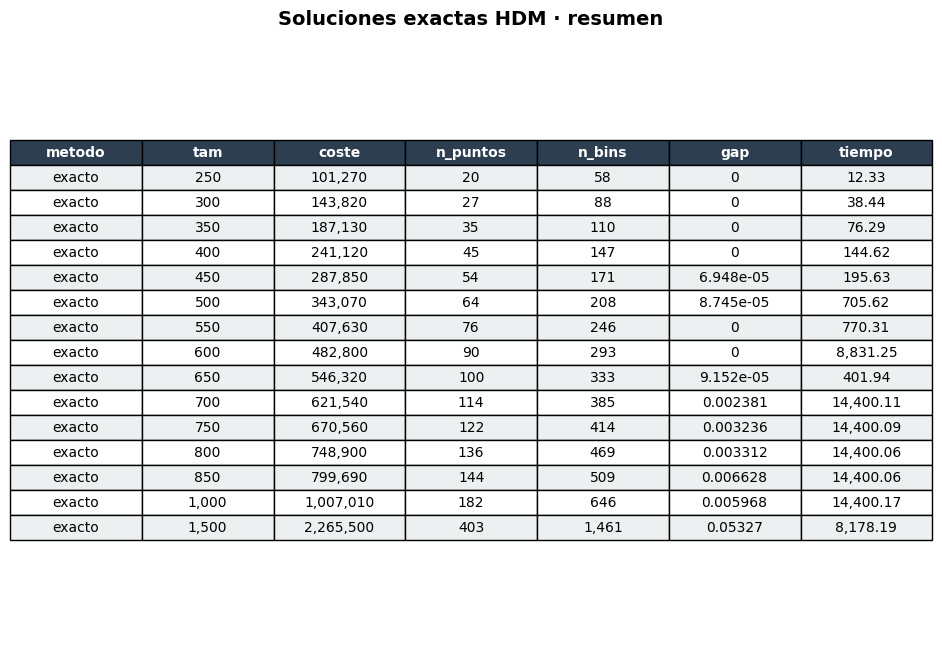

In [ ]:
df_exacto = comparativas.tabla_resumen(SOLS)
display(df_exacto)

ax = comparativas.tabla_matplotlib(df_exacto, titulo="Soluciones exactas HDM · resumen")
ruta = rutas.ruta_figura("02_tabla_resumen")
ruta.parent.mkdir(parents=True, exist_ok=True)
ax.figure.savefig(ruta, dpi=120, bbox_inches="tight")
print(f"Figura guardada: {ruta.relative_to(RAIZ)}")
plt.show()

In [ ]:
for tam in MUESTRA:
    s = SOL[tam]
    fija, variable = metricas.desglose_coste(s.datos, s.inst)
    bpt = metricas.bins_por_tipo(s.datos, s.inst.n_waste_types)
    reparto = "  ".join(f"{estilo.nombre_tipo(k)}={bpt[k]}" for k in sorted(bpt))
    print(f"── {tam} m ──  coste {metricas.coste(s.datos):>12,.0f} € "
          f"= apertura {fija:,.0f} + contenedores {variable:,.0f}")
    print(f"    contenedores por tipo: {reparto}   (total {metricas.total_bins(s.datos)})")

── 500 m ──  coste      343,070 € = apertura 265,800 + contenedores 77,270
    contenedores por tipo: Orgánica=64  Resto=65  Reciclable=51  Peligrosos=28   (total 208)
── 800 m ──  coste      748,900 € = apertura 575,000 + contenedores 173,900
    contenedores por tipo: Orgánica=139  Resto=146  Reciclable=120  Peligrosos=64   (total 469)
── 1000 m ──  coste    1,007,010 € = apertura 767,800 + contenedores 239,210
    contenedores por tipo: Orgánica=189  Resto=202  Reciclable=168  Peligrosos=87   (total 646)
── 1500 m ──  coste    2,265,500 € = apertura 1,723,400 + contenedores 542,100
    contenedores por tipo: Orgánica=414  Resto=446  Reciclable=385  Peligrosos=216   (total 1461)


## 2. Escalabilidad del modelo exacto

Cómo escalan **coste**, **gap** de Gurobi, **tiempo de resolución** y **número de
puntos abiertos** con el tamaño de la instancia (un panel por magnitud, sobre **todos**
los tamaños resueltos; gráfico agregado, D9). En el panel de tiempo se **resaltan** dos
estados de parada, clasificados **aquí en el cuaderno** con `estilo.estado_gurobi`
(lógica específica del exacto; la librería agnóstica solo dibuja los grupos que recibe):
**time-limit** (□, censura por el límite de 4 h) e **interrumpido** (△, interrupción
externa antes del límite). La etiqueta la decide el *status* **crudo** de Gurobi, no el
gap redondeado (D10). Cuando el tiempo deja de ser informativo, la métrica relevante
pasa a ser el **gap** (panel en %, escala lineal), que revela el error real detrás de la
meseta.

time-limit (status 9): [700, 750, 800, 850, 1000]   |   interrumpido (status 11): [1500]
Figura guardada: output/figuras/02_escalabilidad.png


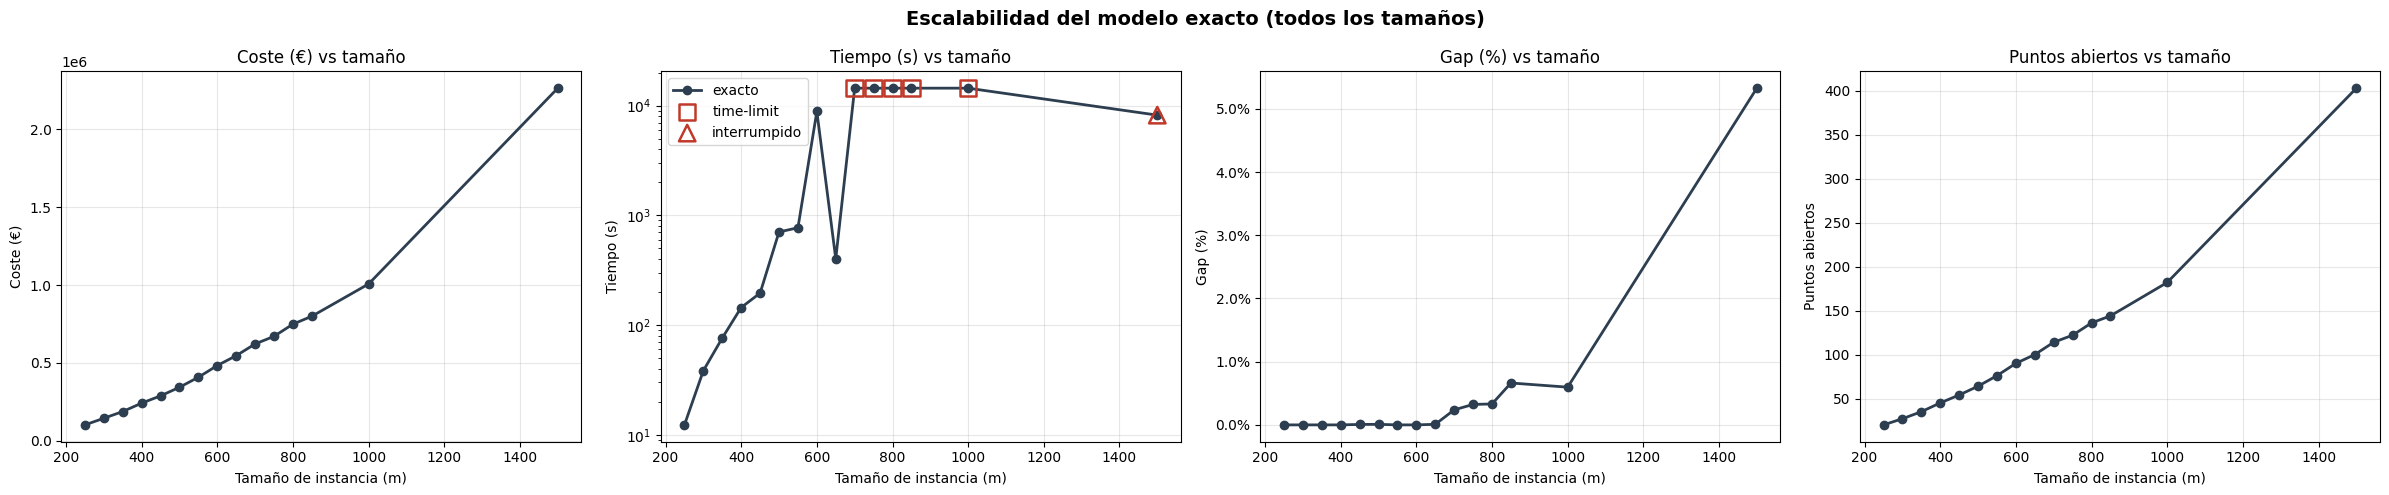

In [ ]:
# Clasificación de estado: lógica ESPECÍFICA DEL EXACTO, vive en el cuaderno (no en la
# librería agnóstica). estilo.estado_gurobi mapea el status CRUDO de Gurobi a etiqueta;
# estilo.MARCADOR_ESTADO fija el marcador de cada estado (única fuente del aspecto).
tl   = [i for i, s in enumerate(SOLS) if estilo.estado_gurobi(s.datos["status"]) == "time-limit"]
intr = [i for i, s in enumerate(SOLS) if estilo.estado_gurobi(s.datos["status"]) == "interrumpido"]

# Un grupo de resaltado por estado; se OMITEN los grupos vacíos (p. ej. si tras el
# git pull ya no queda ninguna instancia interrumpida).
resaltar = []
if tl:
    resaltar.append({"indices": tl, "etiqueta": "time-limit",
                     "marcador": estilo.MARCADOR_ESTADO["time-limit"]})
if intr:
    resaltar.append({"indices": intr, "etiqueta": "interrumpido",
                     "marcador": estilo.MARCADOR_ESTADO["interrumpido"]})

ejes = comparativas.grafico_escalabilidad(
    SOLS,
    columnas=("coste", "tiempo", "gap", "n_puntos"),
    resaltar=resaltar,
)
plt.suptitle("Escalabilidad del modelo exacto (todos los tamaños)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
ruta = rutas.ruta_figura("02_escalabilidad")
ruta.parent.mkdir(parents=True, exist_ok=True)
ejes[0].figure.savefig(ruta, dpi=120, bbox_inches="tight")
print(f"time-limit (status 9): {[SOLS[i].tam for i in tl]}   |   "
      f"interrumpido (status 11): {[SOLS[i].tam for i in intr]}")
print(f"Figura guardada: {ruta.relative_to(RAIZ)}")
plt.show()

In [ ]:
# Narrativa DINÁMICA: lee gap/estado de la solución en disco (dato volátil: el exacto
# 1500m puede re-ejecutarse tras un git pull). NO se hardcodea nada.
tam_max = max(TAMS)
s_max = SOL[tam_max]
gap_max = metricas.gap(s_max.datos)
estado_max = estilo.estado_gurobi(s_max.datos["status"])
tl_tams   = [SOLS[i].tam for i in tl]
intr_tams = [SOLS[i].tam for i in intr]

partes = [
    f"**Hallazgo.** El *gap* despega en el rango medio. Los tamaños **{tl_tams}** "
    f"**agotan el límite de 4 h** (status *time-limit*): el tiempo se **satura** y deja "
    f"de ser informativo.",
]
if intr_tams:
    partes.append(
        f" Los tamaños **{intr_tams}** terminan por **interrupción externa antes del "
        f"límite** (status *interrumpido*) — un caso distinto de la censura por tiempo."
    )
partes.append(
    f" La mayor instancia resuelta hoy (**{tam_max} m**) queda en estado "
    f"**{estado_max}** con *gap* **{gap_max:.2%}**."
)
if 600 in SOL and 650 in SOL:
    partes.append(
        f" El tiempo **no** es monótono con el tamaño ni siquiera entre óptimos: 600 m "
        f"(óptimo, {SOL[600].datos['runtime']:.0f} s) tardó más que 650 m (óptimo, "
        f"{SOL[650].datos['runtime']:.0f} s). La métrica que ordena la dificultad real "
        f"es el **gap**, no el tiempo."
    )
display(Markdown("".join(partes)))

**Hallazgo.** El *gap* despega en el rango medio. Los tamaños **[700, 750, 800, 850, 1000]** **agotan el límite de 4 h** (status *time-limit*): el tiempo se **satura** y deja de ser informativo. Los tamaños **[1500]** terminan por **interrupción externa antes del límite** (status *interrumpido*) — un caso distinto de la censura por tiempo. La mayor instancia resuelta hoy (**1500 m**) queda en estado **interrumpido** con *gap* **5.33%**. El tiempo **no** es monótono con el tamaño ni siquiera entre óptimos: 600 m (óptimo, 8831 s) tardó más que 650 m (óptimo, 402 s). La métrica que ordena la dificultad real es el **gap**, no el tiempo.

## 3. Mapas de solución (muestra)

Un mapa por instancia con `mapas.mapa_solucion` (función única para todo método):
calles de fondo, líneas de asignación edificio→punto (tipo orgánica, k=0),
candidatos cerrados y puntos abiertos con **tamaño ∝ nº de contenedores** y **color ∝
demanda asignada**. Solo para la **muestra** `estilo.RADIOS_MUESTRA` (mapas pesados:
se muestrea, no se pintan los 15; D9).

Figura guardada: output/figuras/02_solucion_500m.png


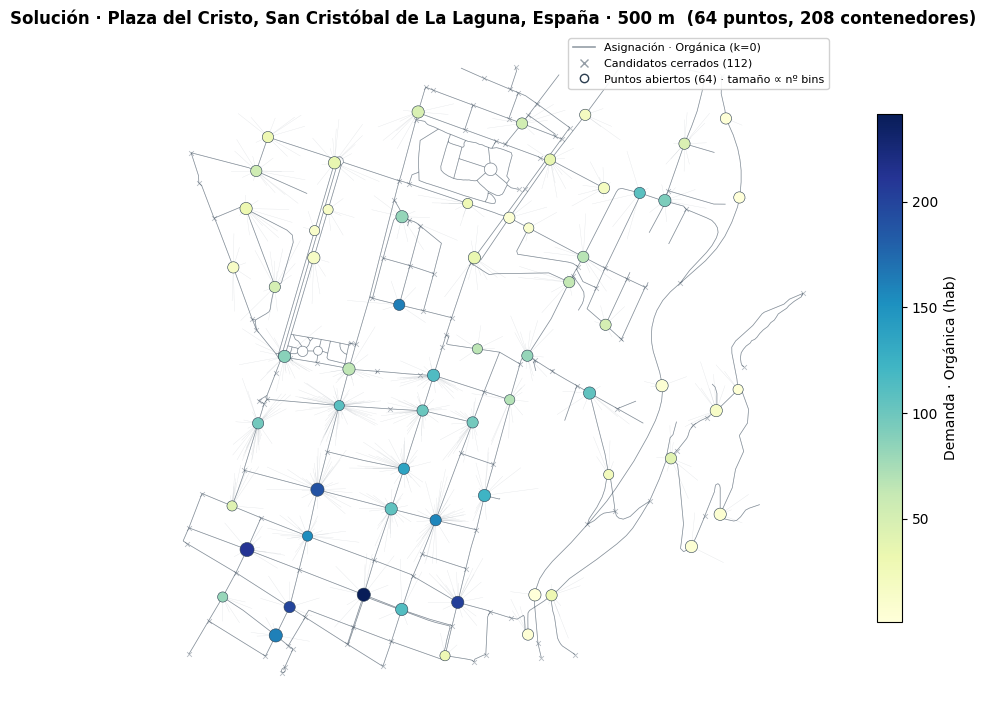

Figura guardada: output/figuras/02_solucion_800m.png


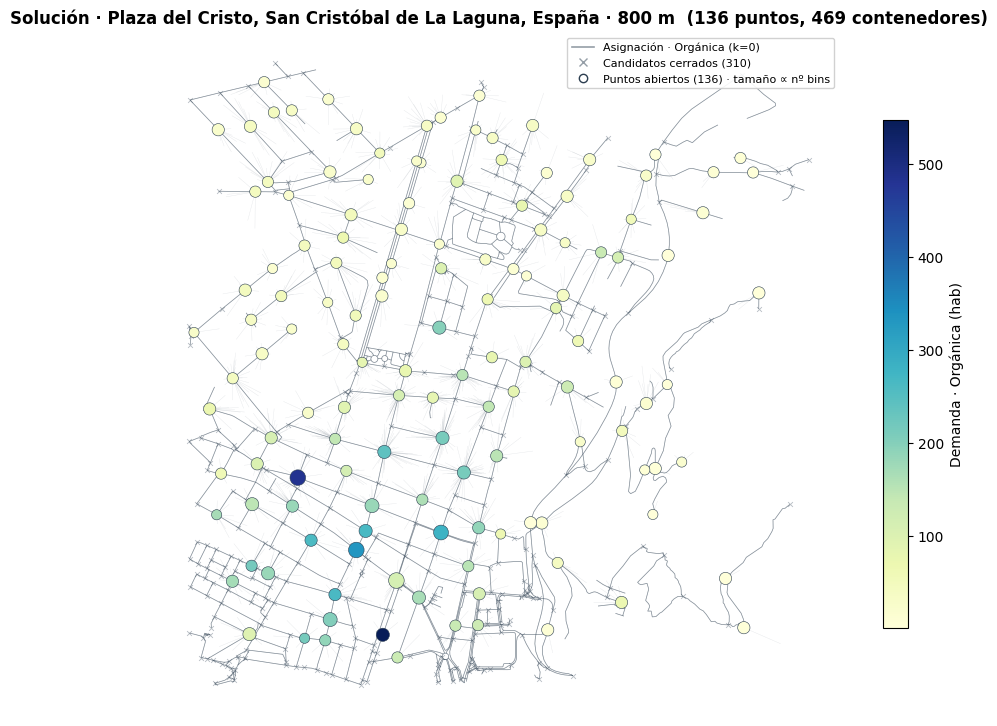

Figura guardada: output/figuras/02_solucion_1000m.png


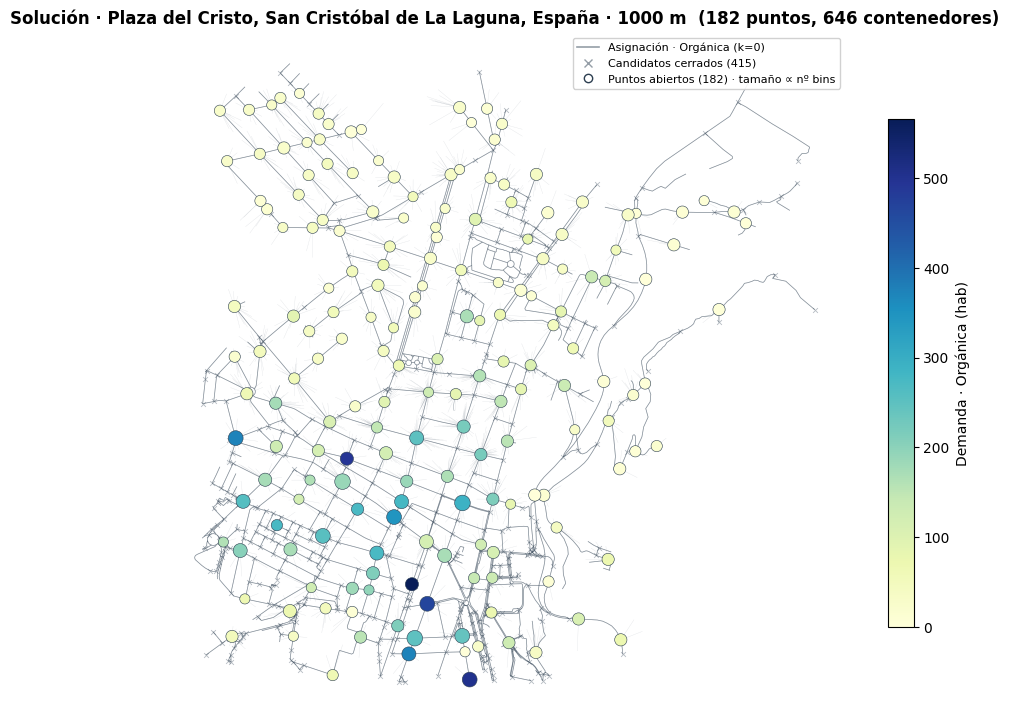

Figura guardada: output/figuras/02_solucion_1500m.png


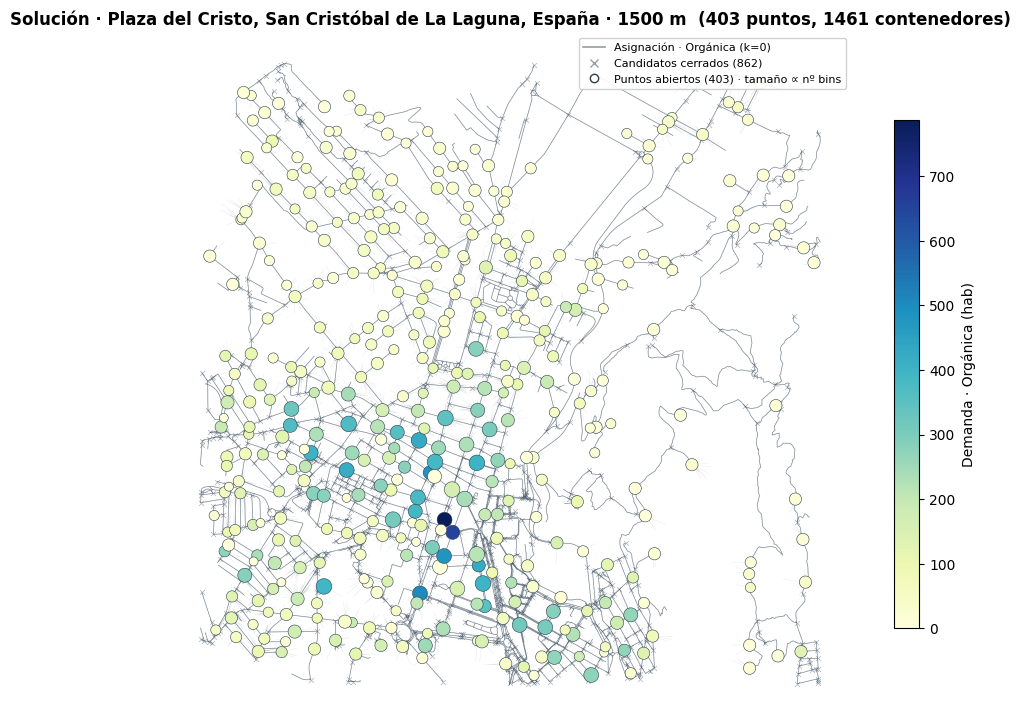

In [ ]:
for tam in MUESTRA:
    s = SOL[tam]
    ax = mapas.mapa_solucion(s.datos, s.inst, rich=True)
    ruta = rutas.ruta_figura(f"02_solucion_{tam}m")
    ruta.parent.mkdir(parents=True, exist_ok=True)
    ax.figure.savefig(ruta, dpi=120, bbox_inches="tight")
    print(f"Figura guardada: {ruta.relative_to(RAIZ)}")
    plt.show()

## Conclusiones

El modelo exacto resuelve el barrido completo con **coste creciente** en el tamaño,
descompuesto exactamente en **apertura + contenedores** (las penalizaciones no aportan
al óptimo determinista). El **tiempo de resolución no es monótono**: un tramo de
tamaños agota el límite de 4 h (*time-limit*, resaltado en el panel de tiempo) mientras
otros mayores terminan antes por interrupción. Cuando el tiempo se satura deja de
ordenar la dificultad; la métrica relevante pasa a ser el **gap**, que despega en el
rango medio. Esta censura temporal es la que **motiva los métodos aproximados**
(lagrangiana y metaheurística) de los cuadernos siguientes. Los mapas de la muestra
ilustran cómo la infraestructura se concentra donde la demanda es alta.